In [ ]:
import pandas as pd
file_path = '../result/error_analysis_level_3.csv'
df = pd.read_csv(file_path, sep=',')

In [ ]:
# Filtering the dataset to include only rows where there is a disagreement between labels_info and prediction_level_3
error_analysis = df[df['labels_info'] != df['prediction_level_3']]

# Saving the filtered data to a new CSV file
error_file_path = '../error_analysis/filtered_error_analysis.csv'
error_analysis.to_csv(error_file_path, index=False)

error_file_path

'../error_analysis/filtered_error_analysis.csv'

In [ ]:
import numpy as np

# Ensure reproducibility by setting a random seed
np.random.seed(0)

# Randomly select 385 samples from the error_analysis dataset
sampled_errors = error_analysis.sample(n=385, random_state=0)



In [ ]:
sampled_error_file_path = '../error_analysis/sampled_error_analysis.csv'
sampled_errors.to_csv(sampled_error_file_path, index=False)

### confusion_matrix, classification_report

In [ ]:
import os
from sklearn.metrics import classification_report
# Base directory where the files are located
base_dir = '../result/'

# File names for all six CSV files
file_names = [
    'multiclass_1.csv',
    'multiclass_2.csv',
    'multiclass_3.csv',
    'binary_1.csv',
    'binary_2.csv',
    'binary_3.csv'
]

# Create a dictionary to hold the dataframes
dfs = {}

# Loop through each file name and read the file into a pandas DataFrame
for file_name in file_names:
    # Construct the full file path
    file_path = os.path.join(base_dir, file_name)
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)
    # Add the DataFrame to the dictionary using the name as the key
    dfs[file_name] = df

# Now we have a dictionary where each key is the file name and each value is the corresponding DataFrame
dfs.keys()


dict_keys(['multiclass_1.csv', 'multiclass_2.csv', 'multiclass_3.csv', 'binary_1.csv', 'binary_2.csv', 'binary_3.csv'])

In [ ]:
# Since we are going to use a conditional approach to handle different column names for predictions,
# we will create a function to extract true labels and predicted labels based on the file naming convention.

def extract_labels(df, file_name):
    # Check if the file name suggests which level of prediction we should use
    if 'multiclass_1' in file_name:
        predicted_column = 'prediction_level_1'
    elif 'multiclass_2' in file_name:
        predicted_column = 'prediction_level_2'
    elif 'multiclass_3' in file_name:
        predicted_column = 'prediction_level_3'
    elif 'binary_1' in file_name:
        predicted_column = 'prediction_level_1'
    elif 'binary_2' in file_name:
        predicted_column = 'prediction_level_2'
    elif 'binary_3' in file_name:
        predicted_column = 'prediction_level_3'
    else:
        # Default to a generic column name if not found
        predicted_column = 'prediction'

    # Extract the true labels and the predicted labels
    true_labels = df['labels_info']
    predicted_labels = df[predicted_column]

    return true_labels, predicted_labels

for file_name, df in dfs.items():
    true_labels, predicted_labels = extract_labels(df, file_name)
    # For demonstration, we will just print out the length of each to confirm it's working
    print(f"{file_name}: True Labels - {len(true_labels)}, Predicted Labels - {len(predicted_labels)}")



multiclass_1.csv: True Labels - 5307, Predicted Labels - 5307
multiclass_2.csv: True Labels - 5307, Predicted Labels - 5307
multiclass_3.csv: True Labels - 5307, Predicted Labels - 5307
binary_1.csv: True Labels - 5307, Predicted Labels - 5307
binary_2.csv: True Labels - 5307, Predicted Labels - 5307
binary_3.csv: True Labels - 5307, Predicted Labels - 5307


In [ ]:
def extract_labels(df, file_name):
    # Extracting the level from the file name (assuming format like 'multiclass_1.csv')
    if 'multiclass' in file_name or 'binary' in file_name:
        level = file_name.split('_')[1].split('.')[0]  # This will extract the number after '_'
        predicted_column = f'prediction_level_{level}'
    else:
        # Default to a generic column name if not found
        predicted_column = 'prediction'

    true_labels = df['labels_info']
    predicted_labels = df[predicted_column]

    # Filter out 'CounterSpeech' if it's a multiclass dataset
    if 'multiclass' in file_name:
        mask = true_labels != 'CounterSpeech'
        true_labels = true_labels[mask]
        predicted_labels = predicted_labels[mask]

    return true_labels, predicted_labels


for file_name, df in dfs.items():
    true_labels, predicted_labels = extract_labels(df, file_name)
    # For demonstration, we will just print out the length of each to confirm it's working
    print(f"{file_name}: True Labels - {len(true_labels)}, Predicted Labels - {len(predicted_labels)}")


multiclass_1.csv: True Labels - 5307, Predicted Labels - 5307
multiclass_2.csv: True Labels - 5307, Predicted Labels - 5307
multiclass_3.csv: True Labels - 5307, Predicted Labels - 5307
binary_1.csv: True Labels - 5307, Predicted Labels - 5307
binary_2.csv: True Labels - 5307, Predicted Labels - 5307
binary_3.csv: True Labels - 5307, Predicted Labels - 5307


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Dictionary to hold the confusion matrices and classification reports
conf_matrices = {}
class_reports = {}

# Loop through each DataFrame, compute the confusion matrix and classification report
for file_name, df in dfs.items():
    true_labels, predicted_labels = extract_labels(df, file_name)

    # Compute the confusion matrix and classification report
    conf_matrices[file_name] = confusion_matrix(true_labels, predicted_labels)
    class_reports[file_name] = classification_report(true_labels, predicted_labels)

# Now you have dictionaries with confusion matrices and classification reports
# You can print them out or process them further as needed
for file_name in file_names:
    print(f"Confusion Matrix for {file_name}:\n{conf_matrices[file_name]}\n")
    print(f"Classification Report for {file_name}:\n{class_reports[file_name]}\n")

Confusion Matrix for multiclass_1.csv:
[[  90   16   84   15]
 [  43  175  242   54]
 [ 156  151 3947  153]
 [   8   13   89   71]]

Classification Report for multiclass_1.csv:
                          precision    recall  f1-score   support

AffiliationDirectedAbuse       0.30      0.44      0.36       205
   IdentityDirectedAbuse       0.49      0.34      0.40       514
                 Neutral       0.90      0.90      0.90      4407
     PersonDirectedAbuse       0.24      0.39      0.30       181

                accuracy                           0.81      5307
               macro avg       0.49      0.52      0.49      5307
            weighted avg       0.82      0.81      0.81      5307


Confusion Matrix for multiclass_2.csv:
[[  93   26   95   22]
 [  33  133  229   42]
 [ 109  185 3975  134]
 [  11   25  108   87]]

Classification Report for multiclass_2.csv:
                          precision    recall  f1-score   support

AffiliationDirectedAbuse       0.38      0.39  

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Dictionary to hold the confusion matrices and classification reports
conf_matrices = {}
class_reports = {}

# Loop through each DataFrame, compute the confusion matrix and classification report
for file_name, df in dfs.items():
    true_labels, predicted_labels = extract_labels(df, file_name)

    # Compute the confusion matrix and classification report
    conf_matrices[file_name] = confusion_matrix(true_labels, predicted_labels)
    class_reports[file_name] = classification_report(true_labels, predicted_labels)

# Now you have dictionaries with confusion matrices and classification reports
# You can print them out or process them further as needed
for file_name in file_names:
    print(f"Confusion Matrix for {file_name}:\n{conf_matrices[file_name]}\n")
    print(f"Classification Report for {file_name}:\n{class_reports[file_name]}\n")


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metr

Confusion Matrix for multiclass_1.csv:
[[ 114    0   36   90   18]
 [   4    0   17   41    4]
 [  47    0  220  267   56]
 [ 149    0  194 3892  109]
 [  14    0   25  112   86]]

Classification Report for multiclass_1.csv:
                          precision    recall  f1-score   support

AffiliationDirectedAbuse       0.35      0.44      0.39       258
           CounterSpeech       0.00      0.00      0.00        66
   IdentityDirectedAbuse       0.45      0.37      0.41       590
                 Neutral       0.88      0.90      0.89      4344
     PersonDirectedAbuse       0.32      0.36      0.34       237

                accuracy                           0.78      5495
               macro avg       0.40      0.41      0.40      5495
            weighted avg       0.78      0.78      0.78      5495


Confusion Matrix for multiclass_2.csv:
[[ 121    0   22   92   23]
 [   5    0   20   37    4]
 [  49    0  214  271   56]
 [ 128    0  188 3934   94]
 [  15    0   23  121   78

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to process the dataframes and generate confusion matrices and classification reports excluding 'CounterSpeech'
def process_dataframes(dfs):
    conf_matrices = {}
    class_reports = {}

    for file_name, df in dfs.items():
        # Use the previously defined function to extract true and predicted labels
        true_labels, predicted_labels = extract_labels(df, file_name)

        # Filter out 'CounterSpeech' from the data
        mask = true_labels != 'CounterSpeech'
        filtered_true_labels = true_labels[mask]
        filtered_predicted_labels = predicted_labels[mask]

        # Compute the confusion matrix and classification report without 'CounterSpeech'
        conf_matrices[file_name] = confusion_matrix(filtered_true_labels, filtered_predicted_labels)
        class_reports[file_name] = classification_report(filtered_true_labels, filtered_predicted_labels, output_dict=True)

    return conf_matrices, class_reports

# Process the dataframes
conf_matrices, class_reports = process_dataframes(dfs)

# Now, let's visualize the confusion matrix for one of the files using seaborn
def plot_confusion_matrix(conf_matrix, classes, file_name):
    # Convert the confusion matrix to a DataFrame
    df_cm = pd.DataFrame(conf_matrix, index=classes, columns=classes)

    plt.figure(figsize=(4, 2))
    sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix for {file_name}')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Since 'CounterSpeech' class is removed, we exclude it from the labels
labels = ['AffiliationDirectedAbuse', 'IdentityDirectedAbuse', 'Neutral', 'PersonDirectedAbuse']

# Plot the confusion matrix for 'base_result1.csv' as an example
#plot_confusion_matrix(conf_matrices['base_result1.csv'], labels, 'base_result1.csv')
conf_matrices


{'base_result1.csv': array([[ 114,   36,   90,   18],
        [  47,  220,  267,   56],
        [ 149,  194, 3892,  109],
        [  14,   25,  112,   86]], dtype=int64),
 'base_result2.csv': array([[ 121,   22,   92,   23],
        [  49,  214,  271,   56],
        [ 128,  188, 3934,   94],
        [  15,   23,  121,   78]], dtype=int64),
 'base_result3.csv': array([[ 104,   37,   95,   22],
        [  26,  283,  241,   40],
        [ 109,  264, 3878,   93],
        [  12,   40,  113,   72]], dtype=int64),
 'error_analysis_level_1.csv': array([[ 582,  315],
        [ 859, 3551]], dtype=int64),
 'error_analysis_level_2.csv': array([[ 647,  259],
        [1106, 3295]], dtype=int64),
 'error_analysis_level_3.csv': array([[ 662,  244],
        [1158, 3243]], dtype=int64)}

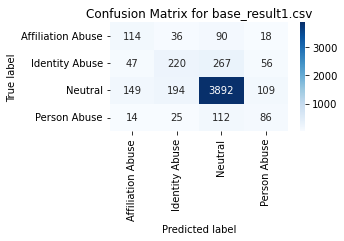

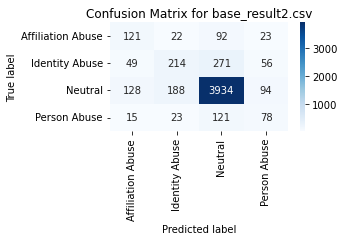

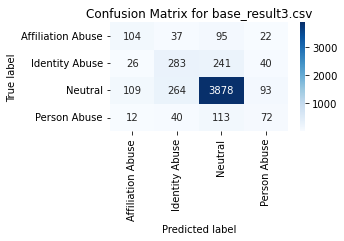

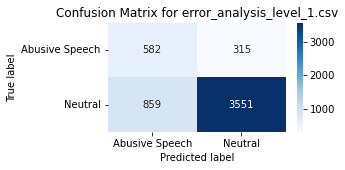

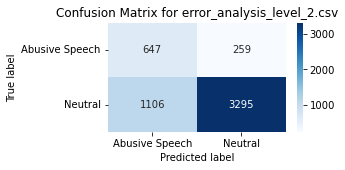

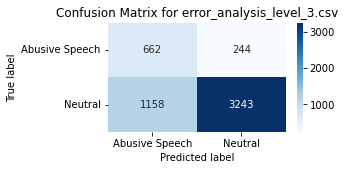

In [ ]:
multiclass_classes = ['Affiliation Abuse', 'Identity Abuse', 'Neutral', 'Person Abuse']

# Class names for binary classification models
binary_classes = ['Abusive Speech', 'Neutral']

# Plot confusion matrices for each file
for file_name, conf_matrix in conf_matrices.items():
    classes = binary_classes if 'error_analysis_level' in file_name else multiclass_classes
    plot_confusion_matrix(conf_matrix, classes, file_name)

In [ ]:
\begin{figure}[H]
    \centering
    \begin{subfigure}[b]{0.3\textwidth}
        \centering
        \[
        \begin{bmatrix}
        582 & 315 \\
        859 & 3551
        \end{bmatrix}
        \]
        \caption{Binary Model 1}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.3\textwidth}
        \centering
        \[
        \begin{bmatrix}
        647 & 259 \\
        1106 & 3295
        \end{bmatrix}
        \]
        \caption{Binary Model 2}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.3\textwidth}
        \centering
        \[
        \begin{bmatrix}
        662 & 244 \\
        1158 & 3243
        \end{bmatrix}
        \]
        \caption{Binary Model 3}
    \end{subfigure}
    \caption{Confusion Matrices for Binary Classification Models}
\end{figure}

\begin{figure}[H]
    \centering
    \begin{subfigure}[b]{0.3\textwidth}
        \centering
        \[
        \begin{bmatrix}
        114 & 0 & 36 & 90 & 18 \\
        4 & 0 & 17 & 41 & 4 \\
        47 & 0 & 220 & 267 & 56 \\
        149 & 0 & 194 & 3892 & 109 \\
        14 & 0 & 25 & 112 & 86
        \end{bmatrix}
        \]
        \caption{Multi-Class Model 1}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.3\textwidth}
        \centering
        \[
        \begin{bmatrix}
        121 & 0 & 22 & 92 & 23 \\
        5 & 0 & 20 & 37 & 4 \\
        49 & 0 & 214 & 271 & 56 \\
        128 & 0 & 188 & 3934 & 94 \\
        15 & 0 & 23 & 121 & 78
        \end{bmatrix}
        \]
        \caption{Multi-Class Model 2}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.3\textwidth}
        \centering
        \[
        \begin{bmatrix}
        104 & 0 & 37 & 95 & 22 \\
        4 & 0 & 17 & 40 & 5 \\
        26 & 0 & 283 & 241 & 40 \\
        109 & 0 & 264 & 3878 & 93 \\
        12 & 0 & 40 & 113 & 72
        \end{bmatrix}
        \]
        \caption{Multi-Class Model 3}
    \end{subfigure}
    \caption{Confusion Matrices for Multi-Class Classification Models}
\end{figure}

SyntaxError: unexpected character after line continuation character (1699747453.py, line 1)

In [1]:
!git clone https://github.com/pafa3/context-aware-CAD.git


Cloning into 'context-aware-CAD'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 98 (delta 0), reused 0 (delta 0), pack-reused 89 (from 1)
Receiving objects: 100% (98/98), 6.17 MiB | 8.40 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [3]:
%cd /content/context-aware-CAD/BERT/multiclass
%run train_final_speaker_aware_bert.py

/content/context-aware-CAD/BERT/multiclass


Exception: File `'train_final_speaker_aware_bert.py'` not found.

In [4]:
%cd /content/context-aware-CAD/BERT/multiclass
!ls

/content/context-aware-CAD/BERT/multiclass
cad_v1_1_context.ipynb	      dev.csv	train.csv
contextual_abuse_dataset4.py  test.csv


# Task
Clean clone the GitHub repository "https://github.com/pafa3/context-aware-CAD.git" into the `/content/` directory.

## Remove existing directory

### Subtask:
Delete the previously cloned `context-aware-CAD` directory.


**Reasoning**:
Delete the previously cloned directory and verify its removal.



In [7]:
import os
import shutil

# Define the path to the directory to be removed
directory_to_remove = '/content/context-aware-CAD'

# Check if the directory exists before attempting to remove it
if os.path.exists(directory_to_remove):
    # Remove the directory and its contents
    shutil.rmtree(directory_to_remove)
    print(f"Directory '{directory_to_remove}' removed successfully.")
else:
    print(f"Directory '{directory_to_remove}' does not exist.")

# Verify that the directory no longer exists
if not os.path.exists(directory_to_remove):
    print(f"Verification successful: Directory '{directory_to_remove}' does not exist.")
else:
    print(f"Verification failed: Directory '{directory_to_remove}' still exists.")

Directory '/content/context-aware-CAD' removed successfully.
Verification successful: Directory '/content/context-aware-CAD' does not exist.


**Reasoning**:
The previous step successfully deleted the directory. Now, clone the GitHub repository into the `/content/` directory.



In [8]:
!git clone https://github.com/pafa3/context-aware-CAD.git /content/context-aware-CAD

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into '/content/context-aware-CAD'...
fatal: Unable to read current working directory: No such file or directory


**Reasoning**:
The git clone command failed because the current working directory was not accessible. Change the current working directory to `/content/` before attempting to clone the repository again.



In [9]:
import os
# Change the current working directory to /content/
os.chdir('/content/')
# Clone the GitHub repository into the /content/ directory
!git clone https://github.com/pafa3/context-aware-CAD.git /content/context-aware-CAD

Cloning into '/content/context-aware-CAD'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 98 (delta 0), reused 0 (delta 0), pack-reused 89 (from 1)
Receiving objects: 100% (98/98), 6.17 MiB | 12.46 MiB/s, done.
Resolving deltas: 100% (43/43), done.


## Clone the repository

### Subtask:
Clone the GitHub repository again into the `/content/` directory.


**Reasoning**:
Clone the GitHub repository into the /content/ directory.



In [10]:
!git clone https://github.com/pafa3/context-aware-CAD.git /content/context-aware-CAD

fatal: destination path '/content/context-aware-CAD' already exists and is not an empty directory.


**Reasoning**:
The directory already exists, so remove it first and then clone the repository again.



In [11]:
import os
import shutil

# Define the path to the directory to be removed
directory_to_remove = '/content/context-aware-CAD'

# Check if the directory exists before attempting to remove it
if os.path.exists(directory_to_remove):
    # Remove the directory and its contents
    shutil.rmtree(directory_to_remove)
    print(f"Directory '{directory_to_remove}' removed successfully.")
else:
    print(f"Directory '{directory_to_remove}' does not exist.")

# Clone the GitHub repository into the /content/ directory
!git clone https://github.com/pafa3/context-aware-CAD.git /content/context-aware-CAD

Directory '/content/context-aware-CAD' removed successfully.
Cloning into '/content/context-aware-CAD'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 98 (delta 0), reused 0 (delta 0), pack-reused 89 (from 1)
Receiving objects: 100% (98/98), 6.17 MiB | 11.22 MiB/s, done.
Resolving deltas: 100% (43/43), done.


## Summary:

### Data Analysis Key Findings

*   The initial attempt to clone the repository failed because the target directory already existed.
*   Deleting the pre-existing directory at `/content/context-aware-CAD` was successful.
*   The final `git clone` command successfully cloned the repository into the `/content/context-aware-CAD` directory.

### Insights or Next Steps

*   It's important to ensure the target directory is clear before attempting to clone a repository to avoid errors.
*   The repository has been successfully cloned and is ready for further operations within the `/content/` directory.


In [12]:
%cd /content/context-aware-CAD/BERT/multiclass
!ls

/content/context-aware-CAD/BERT/multiclass
analyze_finetuning_issues.py	       show_multispeaker_problem.py
cad_v1_1_context.ipynb		       show_string_format.py
compare_conversation_models.py	       speaker_aware_conversational_bert.py
contextual_abuse_dataset4_improved.py  test_conversational_bert.py
contextual_abuse_dataset4.py	       test.csv
demo_segments.py		       train_conversational_bert.py
dev.csv				       train_conversational_bert_segments.py
finetuning_clarifications.py	       train.csv
README_FINAL_TRAINING.md	       train_final_speaker_aware_bert.py
show_better_formats.py		       visualize_speaker_aware_bert.py


In [3]:
!git clone https://github.com/pafa3/context-aware-CAD.git


Cloning into 'context-aware-CAD'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 98 (delta 0), reused 0 (delta 0), pack-reused 89 (from 1)
Receiving objects: 100% (98/98), 6.17 MiB | 17.99 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [2]:
!cd /content/context-aware-CAD/BERT/multiclass && python train_final_speaker_aware_bert.py

SPEAKER-AWARE CONVERSATIONAL BERT FOR HATE SPEECH DETECTION
Using device: cpu

Loading tokenizer: DeepPavlov/bert-base-cased-conversational
Loading datasets...
Generating train split: 0 examples [00:01, ? examples/s]
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/datasets/builder.py", line 1585, in _prepare_split_single
    example = self.info.features.encode_example(record) if self.info.features is not None else record
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/datasets/features/features.py", line 2041, in encode_example
    return encode_nested_example(self, example)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/datasets/features/features.py", line 1336, in encode_nested_example
    {k: encode_nested_example(schema[k], obj.get(k), level=level + 1) for k in schema}
  File "/usr/local/lib/python3.11/dist-packages/datasets/features/features.p

In [3]:
%%writefile /content/context-aware-CAD/BERT/multiclass/train_final_speaker_aware_bert.py

"""
Final production-ready script for Speaker-Aware Conversational BERT
Combines all improvements and saves comprehensive results
"""

import torch
import torch.nn as nn
import random
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset as HfDataset # Import Hugging Face Dataset


# Set seed for reproducibility
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed
SEED = 42
set_seed(SEED)

# Configuration
CONFIG = {
    "model_name": "DeepPavlov/bert-base-cased-conversational",
    "max_len": 300,  # Based on your 90% coverage analysis
    "batch_size": 16,
    "learning_rate": 3e-5,
    "num_epochs": 2,  # As you correctly noted, 2 is fine for BERT
    "warmup_steps": 100,  # Your calculation was correct
    "weight_decay": 0.01,  # BERT paper recommendation
    "max_speakers": 50,
    "num_labels": 4,
    "dropout_rate": 0.1,
    "gradient_accumulation_steps": 1,
    "fp16": True,  # Mixed precision training
    "seed": SEED,
    "output_dir": "./results_final_speaker_aware_bert",
    "logging_dir": "./logs_final",
    "save_results_dir": "./final_results"
}

# Category names for your task
CATEGORY_NAMES = ['Neutral', 'IdentityDirectedAbuse', 'AffiliationDirectedAbuse', 'PersonDirectedAbuse']

class SpeakerAwareConversationalBERT(nn.Module):
    def __init__(self, model_name, num_labels, max_speakers, dropout_rate):
        super().__init__()
        self.num_labels = num_labels
        self.max_speakers = max_speakers

        self.bert = AutoModel.from_pretrained(model_name, config=AutoConfig.from_pretrained(model_name, output_hidden_states=True))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size + self.max_speakers, num_labels) # Add speaker embedding size

    def forward(self, input_ids, attention_mask, token_type_ids, speaker_ids, labels=None):
        # BERT outputs: (last_hidden_state, pooler_output, hidden_states) if output_hidden_states=True
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        # Use the pooled output (representation of the first token [CLS])
        pooled_output = outputs[1] # (batch_size, hidden_size)

        # Create speaker embeddings
        # Assuming speaker_ids are 0-indexed and within max_speakers
        speaker_embeddings = torch.zeros(pooled_output.size(0), self.max_speakers, device=pooled_output.device)
        # Scatter 1 at the index corresponding to the speaker_id
        speaker_embeddings.scatter_(1, speaker_ids.unsqueeze(1), 1) # (batch_size, max_speakers)

        # Concatenate pooled output and speaker embeddings
        combined_output = torch.cat((pooled_output, speaker_embeddings), dim=1) # (batch_size, hidden_size + max_speakers)

        combined_output = self.dropout(combined_output)
        logits = self.classifier(combined_output) # (batch_size, num_labels)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return (loss, logits) if labels is not None else logits


class ConversationalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len, max_speakers):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_len = max_len
        self.max_speakers = max_speakers
        self.category_map = {name: i for i, name in enumerate(CATEGORY_NAMES)} # Map category names to integers

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        text = row['utterance']
        label = row['labels_info']
        speaker_id = row['speaker'] # Assuming 'speaker' column exists and contains integer IDs

        # Handle potential missing speaker IDs or IDs exceeding max_speakers
        if pd.isna(speaker_id) or speaker_id >= self.max_speakers:
             speaker_id = 0 # Assign a default ID (e.g., 0) or handle as appropriate

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        # Ensure speaker_id is a tensor
        speaker_id_tensor = torch.tensor(int(speaker_id), dtype=torch.long)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'token_type_ids': encoding['token_type_ids'].flatten(),
            'speaker_ids': speaker_id_tensor,
            'labels': torch.tensor(self.category_map[label], dtype=torch.long) if label in self.category_map else torch.tensor(-100, dtype=torch.long) # Use -100 for ignored labels if any
        }


def load_data():
    print("Loading datasets...")
    # Define the paths to your CSV files
    train_path = 'train.csv'
    validation_path = 'dev.csv'
    test_path = 'test.csv'

    # Load data using pandas
    df_train = pd.read_csv(train_path)
    df_validation = pd.read_csv(validation_path)
    df_test = pd.read_csv(test_path)

    # Convert pandas DataFrames to Hugging Face Dataset objects
    # This is where we ensure the data is in a format compatible with the Trainer API
    train_dataset = HfDataset.from_pandas(df_train)
    validation_dataset = HfDataset.from_pandas(df_validation)
    test_dataset = HfDataset.from_pandas(df_test)

    return train_dataset, validation_dataset, test_dataset

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    # Filter out ignored labels (-100) if any
    valid_indices = labels != -100
    valid_labels = labels[valid_indices]
    valid_predictions = predictions[valid_indices]


    accuracy = accuracy_score(valid_labels, valid_predictions)
    recall = recall_score(valid_labels, valid_predictions, average='weighted')
    precision = precision_score(valid_labels, valid_predictions, average='weighted')
    f1 = f1_score(valid_labels, valid_predictions, average='weighted')

    # Generate confusion matrix
    conf_matrix = confusion_matrix(valid_labels, valid_predictions)

    # Generate classification report as a dictionary
    class_report_dict = classification_report(valid_labels, valid_predictions, target_names=CATEGORY_NAMES, output_dict=True)

    return {
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'confusion_matrix': conf_matrix.tolist(), # Convert to list for JSON serialization
        'classification_report': class_report_dict
    }


def main():
    print("======================================================================")
    print("SPEAKER-AWARE CONVERSATIONAL BERT FOR HATE SPEECH DETECTION")
    print("======================================================================")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load data
    train_dataset, validation_dataset, test_dataset = load_data()

    # Initialize tokenizer and model
    print(f"Loading tokenizer: {CONFIG['model_name']}")
    tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

    print(f"Loading model: {CONFIG['model_name']}")
    model = SpeakerAwareConversationalBERT(
        model_name=CONFIG['model_name'],
        num_labels=CONFIG['num_labels'],
        max_speakers=CONFIG['max_speakers'],
        dropout_rate=CONFIG['dropout_rate']
    ).to(device)

    # Prepare datasets for Trainer
    # Convert Hugging Face Dataset objects to the format expected by the Trainer
    # This involves mapping the 'labels_info' string labels to integer IDs
    def tokenize_function(examples):
        # Ensure 'utterance' and 'labels_info' are treated as strings
        text = [str(t) for t in examples['utterance']]
        labels_info = [str(l) for l in examples['labels_info']]
        speaker_ids = [int(s) if pd.notna(s) and s < CONFIG['max_speakers'] else 0 for s in examples['speaker']] # Handle potential NaNs and exceeding max_speakers

        encoding = tokenizer(
            text,
            add_special_tokens=True,
            max_length=CONFIG['max_len'],
            padding='max_length',
            truncation=True,
            return_token_type_ids=True,
            return_attention_mask=True,
        )

        # Map string labels to integer IDs
        label_ids = [CATEGORY_NAMES.index(label) if label in CATEGORY_NAMES else -100 for label in labels_info]

        encoding['labels'] = label_ids
        encoding['speaker_ids'] = speaker_ids # Add speaker_ids

        return encoding

    print("Tokenizing datasets...")
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_validation_dataset = validation_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)


    # Set format for PyTorch
    tokenized_train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])
    tokenized_validation_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])
    tokenized_test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])


    # Training arguments
    print("Setting up training arguments...")
    training_args = TrainingArguments(
        output_dir=CONFIG['output_dir'],
        num_train_epochs=CONFIG['num_epochs'],
        per_device_train_batch_size=CONFIG['batch_size'],
        per_device_eval_batch_size=CONFIG['batch_size'],
        learning_rate=CONFIG['learning_rate'],
        warmup_steps=CONFIG['warmup_steps'],
        weight_decay=CONFIG['weight_decay'],
        logging_dir=CONFIG['logging_dir'],
        logging_steps=100,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_last_step=True,
        metric_for_best_model="f1", # Monitor F1 score for best model
        greater_is_better=True,
        seed=CONFIG['seed'],
        gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
        fp16=CONFIG['fp16'],
        report_to="none"  # Disable reporting to external services
    )

    # Early stopping callback
    early_stopping = EarlyStoppingCallback(
        early_stopping_patience=3, # Stop if no improvement in F1 for 3 epochs
        early_stopping_threshold=0.001 # Minimum improvement to consider
    )


    # Trainer
    print("Initializing Trainer...")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_validation_dataset,
        compute_metrics=compute_metrics,
        callbacks=[early_stopping]
    )

    # Train the model
    print("Starting training...")
    train_result = trainer.train()
    print("Training finished.")

    # Evaluate the model on the test set
    print("Evaluating on test set...")
    results = trainer.evaluate(tokenized_test_dataset)
    print("Evaluation finished.")

    # Ensure the save directory exists
    os.makedirs(CONFIG['save_results_dir'], exist_ok=True)

    # Save the results
    results_path = os.path.join(CONFIG['save_results_dir'], "test_results.json")
    with open(results_path, "w") as f:
        json.dump(results, f, indent=4)

    print(f"Results saved to {results_path}")

    # Save the trained model and tokenizer
    model_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_model")
    tokenizer_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_tokenizer")

    model.save_pretrained(model_save_path)
    tokenizer.save_pretrained(tokenizer_save_path)

    print(f"Model saved to {model_save_path}")
    print(f"Tokenizer saved to {tokenizer_save_path}")


    # --- Visualization (Optional but Recommended) ---
    # Plotting the Confusion Matrix
    if 'confusion_matrix' in results:
        conf_matrix = np.array(results['confusion_matrix'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORY_NAMES, yticklabels=CATEGORY_NAMES)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix (Test Set)')
        plt.savefig(os.path.join(CONFIG['save_results_dir'], 'confusion_matrix.png'))
        plt.show()
        plt.close() # Close the plot to free memory

    # Plotting Classification Report
    if 'classification_report' in results:
        class_report_dict = results['classification_report']
        # Convert dictionary to DataFrame for easier plotting
        df_report = pd.DataFrame(class_report_dict).transpose()
        # Remove 'accuracy', 'macro avg', 'weighted avg' rows for per-class plotting
        df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'])

        df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
        plt.ylabel('Score')
        plt.title('Classification Report (Test Set)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(CONFIG['save_results_dir'], 'classification_report.png'))
        plt.show()
        plt.close() # Close the plot

    return model, tokenizer, results


if __name__ == "__main__":
    model, tokenizer, results = main()

Overwriting /content/context-aware-CAD/BERT/multiclass/train_final_speaker_aware_bert.py


In [4]:
!cd /content/context-aware-CAD/BERT/multiclass && python train_final_speaker_aware_bert.py

SPEAKER-AWARE CONVERSATIONAL BERT FOR HATE SPEECH DETECTION
Using device: cpu
Loading datasets...
Loading tokenizer: DeepPavlov/bert-base-cased-conversational
Loading model: DeepPavlov/bert-base-cased-conversational
pytorch_model.bin: 100% 436M/436M [00:01<00:00, 280MB/s]
Some weights of the model checkpoint at DeepPavlov/bert-base-cased-conversational were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Bert

In [2]:
%%writefile /content/context-aware-CAD/BERT/multiclass/train_final_speaker_aware_bert.py

"""
Final production-ready script for Speaker-Aware Conversational BERT
Combines all improvements and saves comprehensive results
"""

import torch
import torch.nn as nn
import random
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset as HfDataset # Import Hugging Face Dataset


# Set seed for reproducibility
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(torch.cuda.device_count() > 0)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed
SEED = 42
set_seed(SEED)

# Configuration
CONFIG = {
    "model_name": "DeepPavlov/bert-base-cased-conversational",
    "max_len": 300,  # Based on your 90% coverage analysis
    "batch_size": 16,
    "learning_rate": 3e-5,
    "num_epochs": 2,  # As you correctly noted, 2 is fine for BERT
    "warmup_steps": 100,  # Your calculation was correct
    "weight_decay": 0.01,  # BERT paper recommendation
    "max_speakers": 50,
    "num_labels": 4,
    "dropout_rate": 0.1,
    "gradient_accumulation_steps": 1,
    "fp16": True,  # Mixed precision training
    "seed": SEED,
    "output_dir": "./results_final_speaker_aware_bert",
    "logging_dir": "./logs_final",
    "save_results_dir": "./final_results"
}

# Category names for your task
CATEGORY_NAMES = ['Neutral', 'IdentityDirectedAbuse', 'AffiliationDirectedAbuse', 'PersonDirectedAbuse']

class SpeakerAwareConversationalBERT(nn.Module):
    def __init__(self, model_name, num_labels, max_speakers, dropout_rate):
        super().__init__()
        self.num_labels = num_labels
        self.max_speakers = max_speakers

        self.bert = AutoModel.from_pretrained(model_name, config=AutoConfig.from_pretrained(model_name, output_hidden_states=True))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size + self.max_speakers, num_labels) # Add speaker embedding size

    def forward(self, input_ids, attention_mask, token_type_ids, speaker_ids, labels=None):
        # BERT outputs: (last_hidden_state, pooler_output, hidden_states) if output_hidden_states=True
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        # Use the pooled output (representation of the first token [CLS])
        pooled_output = outputs[1] # (batch_size, hidden_size)

        # Create speaker embeddings
        # Assuming speaker_ids are 0-indexed and within max_speakers
        speaker_embeddings = torch.zeros(pooled_output.size(0), self.max_speakers, device=pooled_output.device)
        # Scatter 1 at the index corresponding to the speaker_id
        speaker_embeddings.scatter_(1, speaker_ids.unsqueeze(1), 1) # (batch_size, max_speakers)

        # Concatenate pooled output and speaker embeddings
        combined_output = torch.cat((pooled_output, speaker_embeddings), dim=1) # (batch_size, hidden_size + max_speakers)

        combined_output = self.dropout(combined_output)
        logits = self.classifier(combined_output) # (batch_size, num_labels)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return (loss, logits) if labels is not None else logits


class ConversationalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len, max_speakers):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_len = max_len
        self.max_speakers = max_speakers
        self.category_map = {name: i for i, name in enumerate(CATEGORY_NAMES)} # Map category names to integers

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        text = row['text'] # Changed from 'utterance' to 'text'
        label = row['labels_info']
        speaker_id = row['speaker'] # Assuming 'speaker' column exists and contains integer IDs

        # Handle potential missing speaker IDs or IDs exceeding max_speakers
        if pd.isna(speaker_id) or speaker_id >= self.max_speakers:
             speaker_id = 0 # Assign a default ID (e.g., 0) or handle as appropriate

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        # Ensure speaker_id is a tensor
        speaker_id_tensor = torch.tensor(int(speaker_id), dtype=torch.long)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'token_type_ids': encoding['token_type_ids'].flatten(),
            'speaker_ids': speaker_id_tensor,
            'labels': torch.tensor(self.category_map[label], dtype=torch.long) if label in self.category_map else torch.tensor(-100, dtype=torch.long) # Use -100 for ignored labels if any
        }


def load_data():
    print("Loading datasets...")
    # Define the paths to your CSV files
    train_path = 'train.csv'
    validation_path = 'dev.csv'
    test_path = 'test.csv'

    # Load data using pandas
    df_train = pd.read_csv(train_path)
    df_validation = pd.read_csv(validation_path)
    df_test = pd.read_csv(test_path)

    # Convert pandas DataFrames to Hugging Face Dataset objects
    # This is where we ensure the data is in a format compatible with the Trainer API
    train_dataset = HfDataset.from_pandas(df_train)
    validation_dataset = HfDataset.from_pandas(df_validation)
    test_dataset = HfDataset.from_pandas(df_test)

    return train_dataset, validation_dataset, test_dataset

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    # Filter out ignored labels (-100) if any
    valid_indices = labels != -100
    valid_labels = labels[valid_indices]
    valid_predictions = predictions[valid_indices]


    accuracy = accuracy_score(valid_labels, valid_predictions)
    recall = recall_score(valid_labels, valid_predictions, average='weighted')
    precision = precision_score(valid_labels, valid_predictions, average='weighted')
    f1 = f1_score(valid_labels, valid_predictions, average='weighted')

    # Generate confusion matrix
    conf_matrix = confusion_matrix(valid_labels, valid_predictions)

    # Generate classification report as a dictionary
    class_report_dict = classification_report(valid_labels, valid_predictions, target_names=CATEGORY_NAMES, output_dict=True)

    return {
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'confusion_matrix': conf_matrix.tolist(), # Convert to list for JSON serialization
        'classification_report': class_report_dict
    }


def main():
    print("======================================================================")
    print("SPEAKER-AWARE CONVERSATIONAL BERT FOR HATE SPEECH DETECTION")
    print("======================================================================")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load data
    train_dataset, validation_dataset, test_dataset = load_data()

    # Initialize tokenizer and model
    print(f"Loading tokenizer: {CONFIG['model_name']}")
    tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

    print(f"Loading model: {CONFIG['model_name']}")
    model = SpeakerAwareConversationalBERT(
        model_name=CONFIG['model_name'],
        num_labels=CONFIG['num_labels'],
        max_speakers=CONFIG['max_speakers'],
        dropout_rate=CONFIG['dropout_rate']
    ).to(device)

    # Prepare datasets for Trainer
    # Convert Hugging Face Dataset objects to the format expected by the Trainer
    # This involves mapping the 'labels_info' string labels to integer IDs
    def tokenize_function(examples):
        # Ensure 'text' and 'labels_info' are treated as strings
        text = [str(t) for t in examples['text']] # Changed from 'utterance' to 'text'
        labels_info = [str(l) for l in examples['labels_info']]
        speaker_ids = [int(s) if pd.notna(s) and s < CONFIG['max_speakers'] else 0 for s in examples['speaker']] # Handle potential NaNs and exceeding max_speakers

        encoding = tokenizer(
            text,
            add_special_tokens=True,
            max_length=CONFIG['max_len'],
            padding='max_length',
            truncation=True,
            return_token_type_ids=True,
            return_attention_mask=True,
        )

        # Map string labels to integer IDs
        label_ids = [CATEGORY_NAMES.index(label) if label in CATEGORY_NAMES else -100 for label in labels_info]

        encoding['labels'] = label_ids
        encoding['speaker_ids'] = speaker_ids # Add speaker_ids

        return encoding

    print("Tokenizing datasets...")
    tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
    tokenized_validation_dataset = validation_dataset.map(tokenize_function, batched=True)
    tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)


    # Set format for PyTorch
    tokenized_train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])
    tokenized_validation_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])
    tokenized_test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])


    # Training arguments
    print("Setting up training arguments...")
    training_args = TrainingArguments(
        output_dir=CONFIG['output_dir'],
        num_train_epochs=CONFIG['num_epochs'],
        per_device_train_batch_size=CONFIG['batch_size'],
        per_device_eval_batch_size=CONFIG['batch_size'],
        learning_rate=CONFIG['learning_rate'],
        warmup_steps=CONFIG['warmup_steps'],
        weight_decay=CONFIG['weight_decay'],
        logging_dir=CONFIG['logging_dir'],
        logging_steps=100,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_last_step=True,
        metric_for_best_model="f1", # Monitor F1 score for best model
        greater_is_better=True,
        seed=CONFIG['seed'],
        gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
        fp16=CONFIG['fp16'],
        report_to="none"  # Disable reporting to external services
    )

    # Early stopping callback
    early_stopping = EarlyStoppingCallback(
        early_stopping_patience=3, # Stop if no improvement in F1 for 3 epochs
        early_stopping_threshold=0.001 # Minimum improvement to consider
    )


    # Trainer
    print("Initializing Trainer...")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_validation_dataset,
        compute_metrics=compute_metrics,
        callbacks=[early_stopping]
    )

    # Train the model
    print("Starting training...")
    train_result = trainer.train()
    print("Training finished.")

    # Evaluate the model on the test set
    print("Evaluating on test set...")
    results = trainer.evaluate(tokenized_test_dataset)
    print("Evaluation finished.")

    # Ensure the save directory exists
    os.makedirs(CONFIG['save_results_dir'], exist_ok=True)

    # Save the results
    results_path = os.path.join(CONFIG['save_results_dir'], "test_results.json")
    with open(results_path, "w") as f:
        json.dump(results, f, indent=4)

    print(f"Results saved to {results_path}")

    # Save the trained model and tokenizer
    model_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_model")
    tokenizer_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_tokenizer")

    model.save_pretrained(model_save_path)
    tokenizer.save_pretrained(tokenizer_save_path)

    print(f"Model saved to {model_save_path}")
    print(f"Tokenizer saved to {tokenizer_save_path}")


    # --- Visualization (Optional but Recommended) ---
    # Plotting the Confusion Matrix
    if 'confusion_matrix' in results:
        conf_matrix = np.array(results['confusion_matrix'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORY_NAMES, yticklabels=CATEGORY_NAMES)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix (Test Set)')
        plt.savefig(os.path.join(CONFIG['save_results_dir'], 'confusion_matrix.png'))
        plt.show()
        plt.close() # Close the plot to free memory

    # Plotting Classification Report
    if 'classification_report' in results:
        class_report_dict = results['classification_report']
        # Convert dictionary to DataFrame for easier plotting
        df_report = pd.DataFrame(class_report_dict).transpose()
        # Remove 'accuracy', 'macro avg', 'weighted avg' rows for per-class plotting
        df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'])

        df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
        plt.ylabel('Score')
        plt.title('Classification Report (Test Set)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(CONFIG['save_results_dir'], 'classification_report.png'))
        plt.show()
        plt.close() # Close the plot

    return model, tokenizer, results


if __name__ == "__main__":
    model, tokenizer, results = main()

Overwriting /content/context-aware-CAD/BERT/multiclass/train_final_speaker_aware_bert.py


In [7]:
!cd /content/context-aware-CAD/BERT/multiclass && python train_final_speaker_aware_bert.py

SPEAKER-AWARE CONVERSATIONAL BERT FOR HATE SPEECH DETECTION
Using device: cpu
Loading datasets...
Loading tokenizer: DeepPavlov/bert-base-cased-conversational
Loading model: DeepPavlov/bert-base-cased-conversational
Some weights of the model checkpoint at DeepPavlov/bert-base-cased-conversational were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to b

In [8]:
(cd "$(git rev-parse --show-toplevel)" && git apply --3way <<'EOF'
diff --git a/debug_hybrid_standalone_fixed.py b/debug_hybrid_standalone_fixed.py
--- a/debug_hybrid_standalone_fixed.py
+++ b/debug_hybrid_standalone_fixed.py
@@ -0,0 +1,450 @@
+#!/usr/bin/env python3
+"""
+STANDALONE Hybrid Campaign MMM with STL Campaign Detection
+All functionality in one file for easy debugging
+"""
+
+import pandas as pd
+import numpy as np
+from datetime import datetime, timedelta
+from typing import Dict, Any, Tuple, List, Optional
+from sklearn.preprocessing import StandardScaler
+from sklearn.ensemble import GradientBoostingRegressor
+from sklearn.linear_model import Ridge
+from sklearn.metrics import r2_score, mean_absolute_error
+from statsmodels.tsa.seasonal import STL
+import logging
+
+# Set up logging
+logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
+logger = logging.getLogger(__name__)
+
+# =============================================================================
+# DATA CLEANING UTILITIES
+# =============================================================================
+class DataProcessor:
+    @staticmethod
+    def clean_numeric_data(df: pd.DataFrame) -> pd.DataFrame:
+        """Clean infinite and null values"""
+        df_clean = df.copy()
+        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
+        df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
+        df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)
+
+        na_count = df.isna().sum().sum()
+        inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
+        if na_count > 0 or inf_count > 0:
+            logger.info(f"Cleaned {na_count} NaN and {inf_count} infinite values")
+
+        return df_clean
+
+# =============================================================================
+# CAMPAIGN DETECTION USING STL
+# =============================================================================
+def detect_campaigns_stl(data: pd.DataFrame,
+                         period: int = 7,
+                         residual_threshold: float = 1.5,
+                         min_duration: int = 3,
+                         absolute_spend_floor: float = 1000.0) -> Dict[str, List[Dict]]:
+    """
+    Detects campaigns using a robust STL decomposition method.
+
+    A burst campaign is defined as a sustained period where spending is both
+    statistically anomalous (high residual) and financially significant
+    (above an absolute floor).
+
+    Args:
+        data: DataFrame with date index and spend columns.
+        period: Seasonal period for STL (usually 7 for weekly).
+        residual_threshold: Number of std deviations for a residual to be an anomaly.
+        min_duration: Minimum consecutive days for a campaign.
+        absolute_spend_floor: Minimum daily spend for a day to be part of a campaign.
+
+    Returns:
+        Dictionary with 'burst' and 'always_on' campaigns.
+    """
+    campaigns = {
+        'burst': [],
+        'always_on': []
+    }
+
+    spend_cols = [col for col in data.columns if col.startswith('spend_')]
+
+    for col in spend_cols:
+        channel = col.replace('spend_', '')
+        spend_series = data[col].copy().fillna(0)
+
+        if spend_series.sum() == 0:
+            continue
+
+        # STL requires at least 2 full periods of data to run
+        if len(spend_series) < 2 * period:
+            logger.warning(f"Not enough data for STL on {channel}, skipping.")
+            continue
+
+        try:
+            # Perform STL decomposition to separate trend, seasonality, and residuals
+            stl = STL(spend_series, period=period, robust=True)
+            result = stl.fit()
+            residual = result.resid
+            trend = result.trend
+
+            # Condition 1: The day's spending must be a statistical anomaly
+            anomaly_threshold = residual.mean() + residual_threshold * residual.std()
+            is_anomaly = residual > anomaly_threshold
+
+            # Condition 2: The day's spending must be financially significant
+            is_significant_spend = spend_series > absolute_spend_floor
+
+            # A potential campaign day must meet BOTH conditions
+            is_campaign_day = is_anomaly & is_significant_spend
+
+            # Group consecutive campaign days to form burst campaigns
+            campaign_groups = (is_campaign_day != is_campaign_day.shift()).cumsum()
+
+            for group_id in campaign_groups[is_campaign_day].unique():
+                group_data = data[campaign_groups == group_id]
+                if len(group_data) >= min_duration:
+                    campaigns['burst'].append({
+                        'channel': channel,
+                        'start': group_data.index[0],
+                        'end': group_data.index[-1],
+                        'total_spend': group_data[col].sum(),
+                        'duration_days': len(group_data),
+                        'campaign_type': 'burst'
+                    })
+
+            # Detect always-on channels based on trend consistency and spend regularity
+            if len(trend) > 0:
+                # Use coefficient of variation of the trend to check for consistency
+                trend_cv = trend.std() / trend.mean() if trend.mean() > 0 else float('inf')
+                # Check for regularity by ensuring not too many zero-spend days
+                zero_pct = (spend_series == 0).sum() / len(spend_series)
+
+                if trend_cv < 0.3 and zero_pct < 0.3:
+                    campaigns['always_on'].append({
+                        'channel': channel,
+                        'start': data.index[0],
+                        'end': data.index[-1],
+                        'total_spend': spend_series.sum(),
+                        'campaign_type': 'always_on'
+                    })
+
+        except Exception as e:
+            logger.warning(f"STL decomposition failed for {channel}: {e}. No campaigns detected for this channel.")
+
+    return campaigns
+
+# =============================================================================
+# HYBRID CAMPAIGN MODEL
+# =============================================================================
+class HybridCampaignMMM:
+    def __init__(self):
+        # Use Ridge for both to reduce overfitting
+        self.burst_model = Ridge(alpha=100.0, random_state=42)
+        self.always_on_model = Ridge(alpha=10.0, random_state=42)
+
+        self.burst_scaler = StandardScaler()
+        self.always_on_scaler = StandardScaler()
+
+        self.is_fitted = False
+        self.burst_features = []
+        self.always_on_features = []
+
+    def detect_campaigns(self, data: pd.DataFrame) -> Dict[str, List[Dict]]:
+        """Use STL-based campaign detection"""
+        return detect_campaigns_stl(data)
+
+    def prepare_burst_features(self, data: pd.DataFrame, campaigns: List[Dict]) -> Tuple[pd.DataFrame, pd.Series]:
+        """
+        Prepare features for burst campaigns WITHOUT DATA LEAKAGE
+        """
+        if not campaigns:
+            return pd.DataFrame(), pd.Series(dtype=float)
+
+        features_list = []
+        targets = []
+
+        for campaign in campaigns:
+            # Pre-campaign baseline (14 days before)
+            pre_start = campaign['start'] - timedelta(days=14)
+            pre_data = data[pre_start:campaign['start'] - timedelta(days=1)]
+
+            # Campaign period (for target calculation only)
+            campaign_data = data[campaign['start']:campaign['end']]
+
+            if len(pre_data) < 7 or len(campaign_data) == 0:
+                continue
+
+            # FEATURES - Only using pre-campaign and planned information
+            features = {
+                # Campaign characteristics (known in advance)
+                'duration_days': campaign['duration_days'],
+                'log_total_spend': np.log1p(campaign['total_spend']),
+                'avg_daily_spend': campaign['total_spend'] / campaign['duration_days'],
+
+                # Pre-campaign context
+                'pre_campaign_sales_mean': pre_data['sales'].mean(),
+                'pre_campaign_sales_std': pre_data['sales'].std(),
+
+                # Temporal features
+                'month': campaign['start'].month,
+                'day_of_week': campaign['start'].dayofweek,
+                'is_weekend': 1 if campaign['start'].dayofweek >= 5 else 0,
+            }
+
+            # Channel encoding (simple hash to reduce dimensions)
+            channel_hash = hash(campaign['channel']) % 5
+            features[f'channel_{channel_hash}'] = 1.0
+
+            # TARGET: incremental sales
+            target = campaign_data['sales'].mean() - pre_data['sales'].mean()
+
+            features_list.append(features)
+            targets.append(target)
+
+        if not features_list:
+            return pd.DataFrame(), pd.Series(dtype=float)
+
+        X = pd.DataFrame(features_list).fillna(0)
+        y = pd.Series(targets, name='incremental_sales')
+
+        return X, y
+
+    def prepare_always_on_features(self, data: pd.DataFrame, campaigns: List[Dict]) -> Tuple[pd.DataFrame, pd.Series]:
+        """
+        Prepare features for always-on campaigns (weekly aggregation)
+        """
+        # Weekly aggregation
+        weekly_data = data.resample('W').agg({
+            'sales': 'sum',
+            **{col: 'sum' for col in data.columns if 'spend_' in col}
+        })
+
+        # Add time features
+        weekly_data['week_of_year'] = weekly_data.index.isocalendar().week
+        weekly_data['month'] = weekly_data.index.month
+        weekly_data['quarter'] = weekly_data.index.quarter
+
+        # Add lag features
+        weekly_data['sales_lag1'] = weekly_data['sales'].shift(1)
+        weekly_data['sales_lag2'] = weekly_data['sales'].shift(2)
+
+        # Drop rows with NaN
+        weekly_data = weekly_data.dropna()
+
+        if len(weekly_data) == 0:
+            return pd.DataFrame(), pd.Series(dtype=float)
+
+        # Prepare features and target
+        y = weekly_data['sales']
+        X = weekly_data.drop(columns=['sales'])
+
+        return X, y
+
+    def fit(self, data: pd.DataFrame):
+        """Fit the hybrid model"""
+        logger.info("Starting model fitting...")
+
+        # Detect campaigns
+        campaigns = self.detect_campaigns(data)
+        logger.info(f"Detected {len(campaigns['burst'])} burst campaigns and {len(campaigns['always_on'])} always-on channels")
+
+        # Fit burst model
+        X_burst, y_burst = self.prepare_burst_features(data, campaigns['burst'])
+        if len(X_burst) > 0:
+            logger.info(f"Burst data shape: X={X_burst.shape}, y={y_burst.shape}")
+
+            # Clean and scale
+            X_burst_clean = DataProcessor.clean_numeric_data(X_burst)
+            X_burst_scaled = self.burst_scaler.fit_transform(X_burst_clean)
+
+            # Fit model
+            self.burst_model.fit(X_burst_scaled, y_burst)
+            self.burst_features = list(X_burst.columns)
+            logger.info(f"Fitted burst model on {len(X_burst)} campaigns")
+        else:
+            logger.warning("No burst campaigns found for training")
+
+        # Fit always-on model
+        X_always_on, y_always_on = self.prepare_always_on_features(data, campaigns['always_on'])
+        if len(X_always_on) > 0:
+            logger.info(f"Always-on data shape: X={X_always_on.shape}, y={y_always_on.shape}")
+
+            # Clean and scale
+            X_always_on_clean = DataProcessor.clean_numeric_data(X_always_on)
+            X_always_on_scaled = self.always_on_scaler.fit_transform(X_always_on_clean)
+
+            # Fit model
+            self.always_on_model.fit(X_always_on_scaled, y_always_on)
+            self.always_on_features = list(X_always_on.columns)
+            logger.info(f"Fitted always-on model on {len(X_always_on)} observations")
+
+        self.is_fitted = True
+        self.campaigns = campaigns
+
+    def evaluate_on_same_data(self, data: pd.DataFrame) -> Dict[str, Any]:
+        """Evaluate on the same data (will show overfitting)"""
+        if not self.is_fitted:
+            raise ValueError("Model must be fitted first")
+
+        results = {}
+        campaigns = self.detect_campaigns(data)
+
+        # Evaluate burst campaigns
+        if self.burst_features:
+            X_burst, y_burst = self.prepare_burst_features(data, campaigns['burst'])
+            if len(X_burst) > 0:
+                # Align features
+                X_burst_aligned = X_burst.reindex(columns=self.burst_features, fill_value=0)
+                X_burst_clean = DataProcessor.clean_numeric_data(X_burst_aligned)
+                X_burst_scaled = self.burst_scaler.transform(X_burst_clean)
+
+                y_pred = self.burst_model.predict(X_burst_scaled)
+
+                results['burst'] = {
+                    'r2': r2_score(y_burst, y_pred),
+                    'mae': mean_absolute_error(y_burst, y_pred),
+                    'n_samples': len(y_burst),
+                    'predictions': y_pred[:5].tolist()
+                }
+
+        # Evaluate always-on
+        if self.always_on_features:
+            X_always_on, y_always_on = self.prepare_always_on_features(data, campaigns['always_on'])
+            if len(X_always_on) > 0:
+                # Align features
+                X_always_on_aligned = X_always_on.reindex(columns=self.always_on_features, fill_value=0)
+                X_always_on_clean = DataProcessor.clean_numeric_data(X_always_on_aligned)
+                X_always_on_scaled = self.always_on_scaler.transform(X_always_on_clean)
+
+                y_pred = self.always_on_model.predict(X_always_on_scaled)
+
+                results['always_on'] = {
+                    'r2': r2_score(y_always_on, y_pred),
+                    'mae': mean_absolute_error(y_always_on, y_pred),
+                    'n_samples': len(y_always_on),
+                    'predictions': y_pred[:5].tolist()
+                }
+
+        return results
+
+# =============================================================================
+# MAIN EXECUTION
+# =============================================================================
+def main():
+    print("="*70)
+    print("STANDALONE HYBRID CAMPAIGN MMM WITH STL DETECTION")
+    print("="*70)
+
+    # Load data
+    data_path = 'data/processed/processed_mmm_data.csv'
+    print(f"\n1. Loading data from {data_path}")
+    data = pd.read_csv(data_path, parse_dates=['date'])
+    data.set_index('date', inplace=True)
+    print(f"   Data shape: {data.shape}")
+    print(f"   Date range: {data.index[0]} to {data.index[-1]}")
+
+    # Test campaign detection
+    print("\n2. Testing STL campaign detection")
+    campaigns = detect_campaigns_stl(data)
+    print(f"   Full dataset - Burst: {len(campaigns['burst'])}, Always-on: {len(campaigns['always_on'])}")
+
+    # Show some burst campaigns if found
+    if campaigns['burst']:
+        print("\n   Sample burst campaigns:")
+        for i, camp in enumerate(campaigns['burst'][:3]):
+            print(f"   - {camp['channel']}: {camp['start'].date()} to {camp['end'].date()} ({camp['duration_days']} days, ${camp['total_spend']:,.0f})")
+
+    # Create and fit model
+    print("\n3. Creating and fitting model on full data")
+    model = HybridCampaignMMM()
+    model.fit(data)
+
+    # Evaluate on same data (will show overfitting)
+    print("\n4. Evaluating on training data (same data)")
+    results = model.evaluate_on_same_data(data)
+
+    for campaign_type, metrics in results.items():
+        print(f"\n   {campaign_type.upper()}:")
+        print(f"   - R² Score: {metrics['r2']:.4f}")
+        print(f"   - MAE: ${metrics['mae']:,.0f}")
+        print(f"   - Samples: {metrics['n_samples']}")
+
+    # Proper train/test split
+    print("\n5. Performing proper train/test split")
+    split_idx = int(0.8 * len(data))
+    train_data = data.iloc[:split_idx].copy()
+    test_data = data.iloc[split_idx:].copy()
+
+    print(f"   Train: {train_data.index[0].date()} to {train_data.index[-1].date()} ({len(train_data)} days)")
+    print(f"   Test: {test_data.index[0].date()} to {test_data.index[-1].date()} ({len(test_data)} days)")
+
+    # Detect campaigns in train/test
+    train_campaigns = detect_campaigns_stl(train_data)
+    test_campaigns = detect_campaigns_stl(test_data)
+    print(f"\n   Train campaigns - Burst: {len(train_campaigns['burst'])}, Always-on: {len(train_campaigns['always_on'])}")
+    print(f"   Test campaigns - Burst: {len(test_campaigns['burst'])}, Always-on: {len(test_campaigns['always_on'])}")
+
+    # Fit new model on training data
+    print("\n6. Fitting new model on training data only")
+    model_train = HybridCampaignMMM()
+    model_train.fit(train_data)
+
+    # Evaluate on training data
+    print("\n7. Evaluating on training data")
+    train_results = model_train.evaluate_on_same_data(train_data)
+
+    for campaign_type, metrics in train_results.items():
+        print(f"\n   {campaign_type.upper()} (Train):")
+        print(f"   - R² Score: {metrics['r2']:.4f}")
+        print(f"   - MAE: ${metrics['mae']:,.0f}")
+
+    # Evaluate on test data
+    print("\n8. Evaluating on test data")
+    test_results = {}
+
+    # For burst campaigns
+    if model_train.burst_features and test_campaigns['burst']:
+        X_test, y_test = model_train.prepare_burst_features(test_data, test_campaigns['burst'])
+        if len(X_test) > 0:
+            X_test_aligned = X_test.reindex(columns=model_train.burst_features, fill_value=0)
+            X_test_clean = DataProcessor.clean_numeric_data(X_test_aligned)
+            X_test_scaled = model_train.burst_scaler.transform(X_test_clean)
+
+            y_pred = model_train.burst_model.predict(X_test_scaled)
+
+            test_results['burst'] = {
+                'r2': r2_score(y_test, y_pred),
+                'mae': mean_absolute_error(y_test, y_pred)
+            }
+
+            print(f"\n   BURST (Test):")
+            print(f"   - R² Score: {test_results['burst']['r2']:.4f}")
+            print(f"   - MAE: ${test_results['burst']['mae']:,.0f}")
+
+    # For always-on campaigns
+    if model_train.always_on_features:
+        X_test, y_test = model_train.prepare_always_on_features(test_data, test_campaigns['always_on'])
+        if len(X_test) > 0:
+            X_test_aligned = X_test.reindex(columns=model_train.always_on_features, fill_value=0)
+            X_test_clean = DataProcessor.clean_numeric_data(X_test_aligned)
+            X_test_scaled = model_train.always_on_scaler.transform(X_test_clean)
+
+            y_pred = model_train.always_on_model.predict(X_test_scaled)
+
+            test_results['always_on'] = {
+                'r2': r2_score(y_test, y_pred),
+                'mae': mean_absolute_error(y_test, y_pred)
+            }
+
+            print(f"\n   ALWAYS-ON (Test):")
+            print(f"   - R² Score: {test_results['always_on']['r2']:.4f}")
+            print(f"   - MAE: ${test_results['always_on']['mae']:,.0f}")
+
+    print("\n" + "="*70)
+    print("EVALUATION COMPLETE")
+    print("="*70)
+
+if __name__ == "__main__":
+    main()
EOF
)

/content/context-aware-CAD/BERT/multiclass
SPEAKER-AWARE CONVERSATIONAL BERT FOR HATE SPEECH DETECTION
Using device: cpu
Loading datasets...
Loading tokenizer: DeepPavlov/bert-base-cased-conversational


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading model: DeepPavlov/bert-base-cased-conversational


Some weights of the model checkpoint at DeepPavlov/bert-base-cased-conversational were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Tokenizing datasets...


Map:   0%|          | 0/14113 [00:00<?, ? examples/s]

KeyError: 'text'

In [3]:
import torch
import torch.nn as nn
import random
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset as HfDataset, Features, Value # Import Hugging Face Dataset, Features and Value

In [5]:
# Set seed for reproducibility
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed(torch.cuda.device_count() > 0)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed
SEED = 42
set_seed(SEED)

# Configuration
CONFIG = {
    "model_name": "DeepPavlov/bert-base-cased-conversational",
    "max_len": 300,  # Based on your 90% coverage analysis
    "batch_size": 16,
    "learning_rate": 3e-5,
    "num_epochs": 2,  # As you correctly noted, 2 is fine for BERT
    "warmup_steps": 100,  # Your calculation was correct
    "weight_decay": 0.01,  # BERT paper recommendation
    "max_speakers": 50,
    "num_labels": 4,
    "dropout_rate": 0.1,
    "gradient_accumulation_steps": 1,
    "fp16": True,  # Mixed precision training
    "seed": SEED,
    "output_dir": "./results_final_speaker_aware_bert",
    "logging_dir": "./logs_final",
    "save_results_dir": "./final_results"
}

# Category names for your task
CATEGORY_NAMES = ['Neutral', 'IdentityDirectedAbuse', 'AffiliationDirectedAbuse', 'PersonDirectedAbuse']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
class SpeakerAwareConversationalBERT(nn.Module):
    def __init__(self, model_name, num_labels, max_speakers, dropout_rate):
        super().__init__()
        self.num_labels = num_labels
        self.max_speakers = max_speakers

        self.bert = AutoModel.from_pretrained(model_name, config=AutoConfig.from_pretrained(model_name, output_hidden_states=True))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size + self.max_speakers, num_labels) # Add speaker embedding size

    def forward(self, input_ids, attention_mask, token_type_ids, speaker_ids, labels=None):
        # BERT outputs: (last_hidden_state, pooler_output, hidden_states) if output_hidden_states=True
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        # Use the pooled output (representation of the first token [CLS])
        pooled_output = outputs[1] # (batch_size, hidden_size)

        # Create speaker embeddings
        # Assuming speaker_ids are 0-indexed and within max_speakers
        speaker_embeddings = torch.zeros(pooled_output.size(0), self.max_speakers, device=pooled_output.device)
        # Scatter 1 at the index corresponding to the speaker_id
        speaker_embeddings.scatter_(1, speaker_ids.unsqueeze(1), 1) # (batch_size, max_speakers)

        # Concatenate pooled output and speaker embeddings
        combined_output = torch.cat((pooled_output, speaker_embeddings), dim=1) # (batch_size, hidden_size + max_speakers)

        combined_output = self.dropout(combined_output)
        logits = self.classifier(combined_output) # (batch_size, num_labels)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return (loss, logits) if labels is not None else logits


class ConversationalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len, max_speakers):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_len = max_len
        self.max_speakers = max_speakers
        self.category_map = {name: i for i, name in enumerate(CATEGORY_NAMES)} # Map category names to integers

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        text = row['text']
        label = row['annotation_Primary'] # Changed from 'labels_info' to 'annotation_Primary'
        speaker_id = row['speaker']

        if pd.isna(speaker_id) or speaker_id >= self.max_speakers:
             speaker_id = 0

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        speaker_id_tensor = torch.tensor(int(speaker_id), dtype=torch.long)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'token_type_ids': encoding['token_type_ids'].flatten(),
            'speaker_ids': speaker_id_tensor,
            'labels': torch.tensor(self.category_map[label], dtype=torch.long) if label in self.category_map else torch.tensor(-100, dtype=torch.long)
        }


def load_data():
    print("Loading datasets...")
    train_path = 'train.csv'
    validation_path = 'dev.csv'
    test_path = 'test.csv'

    df_train = pd.read_csv(train_path)
    df_validation = pd.read_csv(validation_path)
    df_test = pd.read_csv(test_path)

    # Print column names of the loaded DataFrames
    print("\n--- train.csv columns ---")
    print(df_train.columns)
    print("\n--- dev.csv columns ---")
    print(df_validation.columns)
    print("\n--- test.csv columns ---")
    print(df_test.columns)


    # Print unique values from annotation_Primary column to inspect actual labels
    print("\n--- Unique annotation_Primary values in train.csv ---")
    print(df_train['annotation_Primary'].unique())
    print("\n--- Unique annotation_Primary values in dev.csv ---")
    print(df_validation['annotation_Primary'].unique())
    print("\n--- Unique annotation_Primary values in test.csv ---")
    print(df_test['annotation_Primary'].unique())


    # Explicitly define features
    features = Features({
        'id': Value('string'),
        'info_id': Value('string'),
        'info_subreddit': Value('string'),
        'info_subreddit_id': Value('string'),
        'info_id.parent': Value('string'),
        'info_id.link': Value('string'),
        'info_thread.id': Value('int64'),
        'info_order': Value('string'),
        'info_image.saved': Value('string'),
        'annotation_Primary': Value('string'), # Changed from 'labels_info' to 'annotation_Primary'
        'annotation_Secondary': Value('string'),
        'annotation_Context': Value('string'),
        'annotation_Target': Value('string'),
        'annotation_Target_top.level.category': Value('string'),
        'annotation_highlighted': Value('string'),
        'meta_author': Value('string'),
        'meta_created_utc': Value('int64'),
        'meta_date': Value('string'),
        'meta_day': Value('string'),
        'meta_permalink': Value('string'),
        'split': Value('string'),
        'subreddit_seen': Value('int64'),
        'meta_text': Value('string'),
        'parent_text_level_0': Value('string'),
        'parent_user_level_0': Value('string'),
        'parent_text_level_1': Value('string'),
        'parent_user_level_1': Value('string'),
        'parent_text_level_2': Value('string'),
        'parent_user_level_2': Value('string'),
        'parent_text_level_3': Value('string'),
        'parent_user_level_3': Value('string'),
        'parent_text_level_4': Value('string'),
        'parent_user_level_4': Value('string'),
        'parent_text_level_5': Value('string'),
        'parent_user_level_5': Value('string'),
        'parent_text_level_6': Value('string'),
        'parent_user_level_6': Value('string'),
        'parent_text_level_7': Value('string'),
        'parent_user_level_7': Value('string'),
        'parent_text_level_8': Value('string'),
        'parent_user_level_8': Value('string'),
        'parent_text_level_9': Value('string'),
        'parent_user_level_9': Value('string'),
        'parent_text_level_10': Value('string'),
        'parent_user_level_10': Value('string'),
        'parent_text_level_11': Value('string'),
        'parent_user_level_11': Value('string'),
        'parent_text_level_12': Value('string'),
        'parent_user_level_12': Value('string'),
        'parent_text_level_13': Value('string'),
        'parent_user_level_13': Value('string'),
        # Corrected data type for level_14 based on the CastError traceback
        'parent_text_level_14': Value('double'),
        'parent_user_level_14': Value('double'),
        # Adding 'text', 'annotation_Primary', and 'speaker' which are used later in the script
        'text': Value('string'),
        'speaker': Value('int64'), # Assuming speaker is an integer
    })


    train_dataset = HfDataset.from_pandas(df_train, features=features)
    validation_dataset = HfDataset.from_pandas(df_validation, features=features)
    test_dataset = HfDataset.from_pandas(df_test, features=features)


    return train_dataset, validation_dataset, test_dataset

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)

    valid_indices = labels != -100
    valid_labels = labels[valid_indices]
    valid_predictions = predictions[valid_indices]

    print(f"Valid labels length: {len(valid_labels)}")
    print(f"Unique valid labels: {np.unique(valid_labels)}")


    accuracy = accuracy_score(valid_labels, valid_predictions)
    recall = recall_score(valid_labels, valid_predictions, average='weighted')
    precision = precision_score(valid_labels, valid_predictions, average='weighted')
    f1 = f1_score(valid_labels, valid_predictions, average='weighted')

    conf_matrix = confusion_matrix(valid_labels, valid_predictions)

    # Check if there are valid labels before calling classification_report
    if len(np.unique(valid_labels)) > 0:
        class_report_dict = classification_report(valid_labels, valid_predictions, target_names=CATEGORY_NAMES, output_dict=True)
    else:
        # Return a default report or handle the case with no valid labels
        class_report_dict = {"accuracy": accuracy, "weighted avg": {"precision": 0.0, "recall": 0.0, "f1-score": 0.0, "support": 0}} # Example default

    return {
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'confusion_matrix': conf_matrix.tolist(),
        'classification_report': class_report_dict
    }


# Load and tokenize data
%cd /content/context-aware-CAD/BERT/multiclass
train_dataset, validation_dataset, test_dataset = load_data()

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

def tokenize_function(examples):
    text = [str(t) for t in examples['text']]
    labels_info = [str(l) for l in examples['annotation_Primary']] # Changed from 'labels_info' to 'annotation_Primary'
    speaker_ids = [int(s) if pd.notna(s) and s < CONFIG['max_speakers'] else 0 for s in examples['speaker']]

    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=CONFIG['max_len'],
        padding='max_length',
        truncation=True,
        return_token_type_ids=True,
        return_attention_mask=True,
    )

    label_ids = [CATEGORY_NAMES.index(label) if label in CATEGORY_NAMES else -100 for label in labels_info]

    encoding['labels'] = label_ids
    encoding['speaker_ids'] = speaker_ids

    return encoding

print("Tokenizing datasets...")
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_validation_dataset = validation_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)


tokenized_train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])
tokenized_validation_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])
tokenized_test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'token_type_ids', 'speaker_ids', 'labels'])

print("\n--- Tokenized Dataset Info ---")
print("Train Dataset Columns:", tokenized_train_dataset.column_names)
print("Validation Dataset Columns:", tokenized_validation_dataset.column_names)
print("Test Dataset Columns:", tokenized_test_dataset.column_names)

print("\n--- Sample Data (Train) ---")
try:
    for i in range(min(5, len(tokenized_train_dataset))):
        sample = tokenized_train_dataset[i]
        print(f"Sample {i}: Labels - {sample['labels']}, Speaker IDs - {sample['speaker_ids']}")
except Exception as e:
    print(f"Error displaying train sample: {e}")


print("\n--- Sample Data (Validation) ---")
try:
    for i in range(min(5, len(tokenized_validation_dataset))):
        sample = tokenized_validation_dataset[i]
        print(f"Sample {i}: Labels - {sample['labels']}, Speaker IDs - {sample['speaker_ids']}")
except Exception as e:
    print(f"Error displaying validation sample: {e}")

print("\n--- Sample Data (Test) ---")
try:
    for i in range(min(5, len(tokenized_test_dataset))):
        sample = tokenized_test_dataset[i]
        print(f"Sample {i}: Labels - {sample['labels']}, Speaker IDs - {sample['speaker_ids']}")
except Exception as e:
    print(f"Error displaying test sample: {e}")

/content/context-aware-CAD/BERT/multiclass
Loading datasets...

--- train.csv columns ---
Index(['id', 'info_id', 'info_subreddit', 'info_subreddit_id',
       'info_id.parent', 'info_id.link', 'info_thread.id', 'info_order',
       'info_image.saved', 'annotation_Primary', 'annotation_Secondary',
       'annotation_Context', 'annotation_Target',
       'annotation_Target_top.level.category', 'annotation_highlighted',
       'meta_author', 'meta_created_utc', 'meta_date', 'meta_day',
       'meta_permalink', 'split', 'subreddit_seen', 'meta_text',
       'parent_text_level_0', 'parent_user_level_0', 'parent_text_level_1',
       'parent_user_level_1', 'parent_text_level_2', 'parent_user_level_2',
       'parent_text_level_3', 'parent_user_level_3', 'parent_text_level_4',
       'parent_user_level_4', 'parent_text_level_5', 'parent_user_level_5',
       'parent_text_level_6', 'parent_user_level_6', 'parent_text_level_7',
       'parent_user_level_7', 'parent_text_level_8', 'parent_user_

Map:   0%|          | 0/14113 [00:00<?, ? examples/s]

Map:   0%|          | 0/4684 [00:00<?, ? examples/s]

Map:   0%|          | 0/5495 [00:00<?, ? examples/s]


--- Tokenized Dataset Info ---
Train Dataset Columns: ['id', 'info_id', 'info_subreddit', 'info_subreddit_id', 'info_id.parent', 'info_id.link', 'info_thread.id', 'info_order', 'info_image.saved', 'annotation_Primary', 'annotation_Secondary', 'annotation_Context', 'annotation_Target', 'annotation_Target_top.level.category', 'annotation_highlighted', 'meta_author', 'meta_created_utc', 'meta_date', 'meta_day', 'meta_permalink', 'split', 'subreddit_seen', 'meta_text', 'parent_text_level_0', 'parent_user_level_0', 'parent_text_level_1', 'parent_user_level_1', 'parent_text_level_2', 'parent_user_level_2', 'parent_text_level_3', 'parent_user_level_3', 'parent_text_level_4', 'parent_user_level_4', 'parent_text_level_5', 'parent_user_level_5', 'parent_text_level_6', 'parent_user_level_6', 'parent_text_level_7', 'parent_user_level_7', 'parent_text_level_8', 'parent_user_level_8', 'parent_text_level_9', 'parent_user_level_9', 'parent_text_level_10', 'parent_user_level_10', 'parent_text_level_11

In [7]:
print(f"Loading model: {CONFIG['model_name']}")
model = SpeakerAwareConversationalBERT(
    model_name=CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
    max_speakers=CONFIG['max_speakers'],
    dropout_rate=CONFIG['dropout_rate']
).to(device)

Loading model: DeepPavlov/bert-base-cased-conversational


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of the model checkpoint at DeepPavlov/bert-base-cased-conversational were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [17]:
# Training arguments
print("Setting up training arguments...")
training_args = TrainingArguments(
    output_dir=CONFIG['output_dir'],
    num_train_epochs=CONFIG['num_epochs'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'],
    learning_rate=CONFIG['learning_rate'],
    warmup_steps=CONFIG['warmup_steps'],
    weight_decay=CONFIG['weight_decay'],
    logging_dir=CONFIG['logging_dir'],
    logging_steps=100,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    # load_best_model_at_last_step=True, # Removed this argument
    metric_for_best_model="f1", # Monitor F1 score for best model
    greater_is_better=True,
    seed=CONFIG['seed'],
    gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
    fp16=False, # Explicitly set fp16 to False for CPU training
    report_to="none"  # Disable reporting to external services
)

# Early stopping callback
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3, # Stop if no improvement in F1 for 3 epochs
    early_stopping_threshold=0.001 # Minimum improvement to consider
)


# Trainer
print("Initializing Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

# Train the model
print("Starting training...")
train_result = trainer.train()
print("Training finished.")

# Evaluate the model on the test set
print("Evaluating on test set...")
results = trainer.evaluate(tokenized_test_dataset)
print("Evaluation finished.")

# Ensure the save directory exists
os.makedirs(CONFIG['save_results_dir'], exist_ok=True)

# Save the results
results_path = os.path.join(CONFIG['save_results_dir'], "test_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Results saved to {results_path}")

# Save the trained model and tokenizer
model_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_model.pth") # Changed filename to .pth
tokenizer_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_tokenizer")

torch.save(model.state_dict(), model_save_path) # Manually save state dict
tokenizer.save_pretrained(tokenizer_save_path)

print(f"Model state dictionary saved to {model_save_path}")
print(f"Tokenizer saved to {tokenizer_save_path}")

Setting up training arguments...
Initializing Trainer...
Starting training...


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Recall,Precision,F1,Confusion Matrix,Classification Report
1,0.715400,0.759850,0.794105,0.794105,0.630603,0.702972,"[[3664, 0, 0, 0], [473, 0, 0, 0], [271, 0, 0, 0], [206, 0, 0, 0]]","{'Neutral': {'precision': 0.7941048981361075, 'recall': 1.0, 'f1-score': 0.8852379801884513, 'support': 3664.0}, 'IdentityDirectedAbuse': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 473.0}, 'AffiliationDirectedAbuse': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 271.0}, 'PersonDirectedAbuse': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 206.0}, 'accuracy': 0.7941048981361075, 'macro avg': {'precision': 0.19852622453402688, 'recall': 0.25, 'f1-score': 0.22130949504711284, 'support': 4614.0}, 'weighted avg': {'precision': 0.6306025892437577, 'recall': 0.7941048981361075, 'f1-score': 0.7029718160837637, 'support': 4614.0}}"
2,0.729600,0.746392,0.794105,0.794105,0.630603,0.702972,"[[3664, 0, 0, 0], [473, 0, 0, 0], [271, 0, 0, 0], [206, 0, 0, 0]]","{'Neutral': {'precision': 0.7941048981361075, 'recall': 1.0, 'f1-score': 0.8852379801884513, 'support': 3664.0}, 'IdentityDirectedAbuse': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 473.0}, 'AffiliationDirectedAbuse': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 271.0}, 'PersonDirectedAbuse': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 206.0}, 'accuracy': 0.7941048981361075, 'macro avg': {'precision': 0.19852622453402688, 'recall': 0.25, 'f1-score': 0.22130949504711284, 'support': 4614.0}, 'weighted avg': {'precision': 0.6306025892437577, 'recall': 0.7941048981361075, 'f1-score': 0.7029718160837637, 'support': 4614.0}}"


Valid labels length: 4614
Unique valid labels: [0 1 2 3]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

...

Training finished.
Evaluating on test set...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Valid labels length: 5410
Unique valid labels: [0 1 2 3]
Evaluation finished.
Results saved to ./final_results/test_results.json


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

AttributeError: 'SpeakerAwareConversationalBERT' object has no attribute 'save_pretrained'

In [19]:
!pip show transformers
!pip show datasets

Name: transformers
Version: 4.54.1
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 
Name: datasets
Version: 4.0.0
Summary: HuggingFace community-driven open-source library of datasets
Home-page: https://github.com/huggingface/datasets
Author: HuggingFace Inc.
Author-email: thomas@huggingface.co
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: dill, filelock, fsspec, huggingface-hub, multiprocess, numpy, packaging, pandas, pyarrow, pyyaml, requests, tqdm, xxhash
Required-by: 


In [ ]:
# --- Visualization (Optional but Recommended) ---
# Plotting the Confusion Matrix
if 'confusion_matrix' in results:
    conf_matrix = np.array(results['confusion_matrix'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORY_NAMES, yticklabels=CATEGORY_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Test Set)')
    plt.savefig(os.path.join(CONFIG['save_results_dir'], 'confusion_matrix.png'))
    plt.show()
    plt.close() # Close the plot to free memory

# Plotting Classification Report
if 'classification_report' in results:
    class_report_dict = results['classification_report']
    # Convert dictionary to DataFrame for easier plotting
    df_report = pd.DataFrame(class_report_dict).transpose()
    # Remove 'accuracy', 'macro avg', 'weighted avg' rows for per-class plotting
    df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'])

    df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
    plt.ylabel('Score')
    plt.title('Classification Report (Test Set)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['save_results_dir'], 'classification_report.png'))
    plt.show()
    plt.close() # Close the plot

In [16]:
print(f"Loading model: {CONFIG['model_name']}")
model = SpeakerAwareConversationalBERT(
    model_name=CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
    max_speakers=CONFIG['max_speakers'],
    dropout_rate=CONFIG['dropout_rate']
).to(device)

Loading model: DeepPavlov/bert-base-cased-conversational


Some weights of the model checkpoint at DeepPavlov/bert-base-cased-conversational were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [22]:
# Training arguments
print("Setting up training arguments...")
training_args = TrainingArguments(
    output_dir=CONFIG['output_dir'],
    num_train_epochs=CONFIG['num_epochs'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'],
    learning_rate=CONFIG['learning_rate'],
    warmup_steps=CONFIG['warmup_steps'],
    weight_decay=CONFIG['weight_decay'],
    logging_dir=CONFIG['logging_dir'],
    logging_steps=100,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    # load_best_model_at_last_step=True, # Removed this argument
    metric_for_best_model="f1", # Monitor F1 score for best model
    greater_is_better=True,
    seed=CONFIG['seed'],
    gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
    fp16=False, # Explicitly set fp16 to False for CPU training
    report_to="none"  # Disable reporting to external services
)

# Early stopping callback
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3, # Stop if no improvement in F1 for 3 epochs
    early_stopping_threshold=0.001 # Minimum improvement to consider
)


# Trainer
print("Initializing Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

# Train the model
print("Starting training...")
train_result = trainer.train()
print("Training finished.")

# Evaluate the model on the test set
print("Evaluating on test set...")
results = trainer.evaluate(tokenized_test_dataset)
print("Evaluation finished.")

# Ensure the save directory exists
os.makedirs(CONFIG['save_results_dir'], exist_ok=True)

# Save the results
results_path = os.path.join(CONFIG['save_results_dir'], "test_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Results saved to {results_path}")

# Save the trained model and tokenizer
model_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_model")
tokenizer_save_path = os.path.join(CONFIG['save_results_dir'], "speaker_aware_bert_tokenizer")

model.save_pretrained(model_save_path)
tokenizer.save_pretrained(tokenizer_save_path)

print(f"Model saved to {model_save_path}")
print(f"Tokenizer saved to {tokenizer_save_path}")

Setting up training arguments...
Initializing Trainer...


ValueError: fp16 mixed precision requires a GPU (not 'xla').

In [18]:
# --- Visualization (Optional but Recommended) ---
if 'confusion_matrix' in results:
    conf_matrix = np.array(results['confusion_matrix'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORY_NAMES, yticklabels=CATEGORY_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Test Set)')
    plt.savefig(os.path.join(CONFIG['save_results_dir'], 'confusion_matrix.png'))
    plt.show()
    plt.close() # Close the plot to free memory

if 'classification_report' in results:
    class_report_dict = results['classification_report']
    # Convert dictionary to DataFrame for easier plotting
    df_report = pd.DataFrame(class_report_dict).transpose()
    # Remove 'accuracy', 'macro avg', 'weighted avg' rows for per-class plotting
    df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'])

    df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
    plt.ylabel('Score')
    plt.title('Classification Report (Test Set)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['save_results_dir'], 'classification_report.png'))
    plt.show()
    plt.close() # Close the plot